Extracting features from videos...
Training started on cpu...
Epoch 01 | Train Acc: 39.22% | Val Acc: 72.73%
Epoch 02 | Train Acc: 44.12% | Val Acc: 72.73%
Epoch 03 | Train Acc: 40.20% | Val Acc: 72.73%
Epoch 04 | Train Acc: 47.06% | Val Acc: 72.73%
Epoch 05 | Train Acc: 48.04% | Val Acc: 72.73%
Epoch 06 | Train Acc: 52.94% | Val Acc: 77.27%
Epoch 07 | Train Acc: 46.08% | Val Acc: 77.27%
Epoch 08 | Train Acc: 53.92% | Val Acc: 77.27%
Epoch 09 | Train Acc: 54.90% | Val Acc: 77.27%
Epoch 10 | Train Acc: 53.92% | Val Acc: 72.73%
Epoch 11 | Train Acc: 59.80% | Val Acc: 72.73%
Epoch 12 | Train Acc: 55.88% | Val Acc: 72.73%
Epoch 13 | Train Acc: 64.71% | Val Acc: 72.73%
Epoch 14 | Train Acc: 61.76% | Val Acc: 81.82%
Epoch 15 | Train Acc: 60.78% | Val Acc: 77.27%
Epoch 16 | Train Acc: 71.57% | Val Acc: 72.73%
Epoch 17 | Train Acc: 67.65% | Val Acc: 72.73%
Epoch 18 | Train Acc: 62.75% | Val Acc: 72.73%
Epoch 19 | Train Acc: 70.59% | Val Acc: 81.82%
Epoch 20 | Train Acc: 71.57% | Val Acc: 90.91

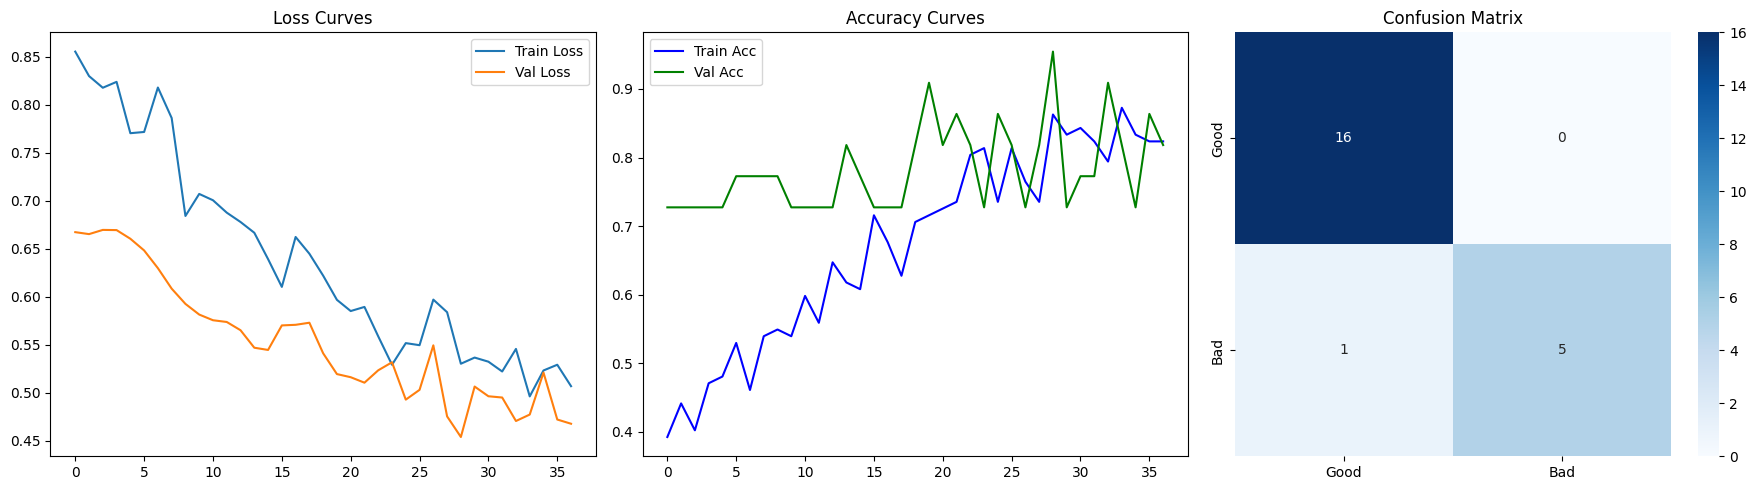

In [12]:
import cv2
import mediapipe as mp
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================================
# CONFIG
# ============================================================================
VIDEO_DIR = r"C:\Users\PRASHANTH\gcn"
SEQ_LEN = 30
BATCH_SIZE = 16
EPOCHS = 100
LEARNING_RATE = 3e-4

# Defined graph connections for a 17-landmark skeleton
ADJ = [
    (0,1),(0,2),(1,3),(2,4), (5,6),(5,7),(7,9),(6,8),(8,10),
    (11,12),(11,13),(13,15),(12,14),(14,16), (5,11),(6,12)
]

def get_adj_matrix():
    A = np.eye(17)
    for i, j in ADJ:
        A[i, j] = A[j, i] = 1
    D = np.diag(np.sum(A, axis=1)**-0.5)
    A_norm = D @ A @ D
    return torch.FloatTensor(A_norm)

# ============================================================================
# AUGMENTATION & PREPROCESSING
# ============================================================================
class SkeletonUtils:
    @staticmethod
    def normalize(coords):
        for i in range(len(coords)):
            # Centering around the mid-hip
            mid_hip = (coords[i, 11, :] + coords[i, 12, :]) / 2
            coords[i] -= mid_hip
        return coords

    @staticmethod
    def add_noise(x, sigma=0.02):
        noise = torch.randn_like(x) * sigma
        return x + noise

    @staticmethod
    def augment(x):
        x = SkeletonUtils.add_noise(x)
        if torch.rand(1) > 0.5: # Random horizontal flip
            x[:, :, [0]] = -x[:, :, [0]]
        scale = 1 + (torch.rand(1) - 0.5) * 0.2
        x = x * scale
        return x

    @staticmethod
    def calculate_angle(a, b, c):
        a, b, c = np.array(a), np.array(b), np.array(c)
        ba = a - b
        bc = c - b
        cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
        angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))
        return np.degrees(angle)

# ============================================================================
# SQUAT PROCESSOR
# ============================================================================
class SquatProcessor:
    def __init__(self):
        self.pose = mp.solutions.pose.Pose(static_image_mode=False, min_detection_confidence=0.5)

    def get_si(self, left_angle, right_angle):
        return ((left_angle - right_angle) / (0.5 * (left_angle + right_angle) + 1e-6)) * 100

    def process_video(self, path):
        cap = cv2.VideoCapture(path)
        coords = []
        frame_labels = []
        video_id = os.path.basename(path)

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = self.pose.process(img)

            if res.pose_landmarks and res.pose_world_landmarks:
                pts = [[lm.x, lm.y, lm.z] for lm in res.pose_landmarks.landmark[12:29]]
                coords.append(pts)

                wlm = res.pose_world_landmarks.landmark
                left_knee = SkeletonUtils.calculate_angle(
                    [wlm[23].x, wlm[23].y, wlm[23].z],
                    [wlm[25].x, wlm[25].y, wlm[25].z],
                    [wlm[27].x, wlm[27].y, wlm[27].z]
                )
                right_knee = SkeletonUtils.calculate_angle(
                    [wlm[24].x, wlm[24].y, wlm[24].z],
                    [wlm[26].x, wlm[26].y, wlm[26].z],
                    [wlm[28].x, wlm[28].y, wlm[28].z]
                )
                si = self.get_si(left_knee, right_knee)
                frame_labels.append(1 if si > 10 else 0)

        cap.release()
        if len(coords) < SEQ_LEN:
            return None, None, None

        coords = SkeletonUtils.normalize(np.array(coords))
        final_label = 1 if np.mean(frame_labels) > 0.4 else 0
        return coords, final_label, video_id

# ============================================================================
# CTR-GCN MODEL
# ============================================================================
class CTR_GC(nn.Module):
    def __init__(self, in_c, out_c, adj):
        super().__init__()
        self.adj = nn.Parameter(adj, requires_grad=False)
        self.refine = nn.Conv2d(in_c, out_c, 1)
        self.pa = nn.Parameter(torch.randn(out_c, 17, 17) * 0.01)
        self.alpha = nn.Parameter(torch.ones(1))

    def forward(self, x):
        x = self.refine(x)
        A = self.alpha * self.adj.unsqueeze(0) + self.pa
        x = torch.einsum('bctv,cvw->bctw', x, A)
        return x

class CTRGCN_Block(nn.Module):
    def __init__(self, in_c, out_c, adj, stride=1):
        super().__init__()
        self.gcn = CTR_GC(in_c, out_c, adj)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, (9, 1), (stride, 1), (4, 0)),
            nn.BatchNorm2d(out_c),
            nn.Dropout(0.6)
        )
        self.res = nn.Conv2d(in_c, out_c, 1) if in_c != out_c else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.tcn(self.gcn(x)) + self.res(x))

class CTRGCN(nn.Module):
    def __init__(self):
        super().__init__()
        adj = get_adj_matrix()
        self.layer1 = CTRGCN_Block(3, 32, adj)
        self.dropout = nn.Dropout(0.5)
        self.layer2 = CTRGCN_Block(32, 16, adj)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.fc(x)

# ============================================================================
# EVALUATION & MAIN
# ============================================================================
def evaluate(model, loader, device, criterion=None):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            if criterion:
                loss = criterion(output, target)
                total_loss += loss.item()
            all_preds.extend(torch.argmax(output, 1).cpu().numpy())
            all_labels.extend(target.cpu().numpy())
    return accuracy_score(all_labels, all_preds), total_loss/len(loader) if criterion else 0, all_labels, all_preds

def main():
    proc = SquatProcessor()
    videos = glob.glob(os.path.join(VIDEO_DIR, "*.mp4"))
    X, y = [], []

    print("Extracting features from videos...")
    for v in videos:
        coords, label, _ = proc.process_video(v)
        if coords is not None:
            # Create sliding windows of SEQ_LEN
            for i in range(0, len(coords) - SEQ_LEN, 10):
                X.append(coords[i:i+SEQ_LEN].transpose(2, 0, 1))
                y.append(label)

    if not X:
        print("No valid data found. Check your VIDEO_DIR path.")
        return

    X = torch.FloatTensor(np.array(X))
    y = torch.LongTensor(np.array(y))

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

    train_loader = DataLoader(list(zip(X_train, y_train)), BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(list(zip(X_val, y_val)), BATCH_SIZE)
    test_loader = DataLoader(list(zip(X_test, y_test)), BATCH_SIZE)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = CTRGCN().to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.20)
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-2)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience = 8
    counter = 0

    print(f"Training started on {device}...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        correct_train = 0
        total_train = 0

        for data, target in train_loader:
            data = SkeletonUtils.augment(data)
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total_train += target.size(0)
            correct_train += (predicted == target).sum().item()

        # Metrics for the current epoch
        train_acc = correct_train / total_train
        val_acc, val_loss, _, _ = evaluate(model, val_loader, device, criterion)
        
        history['train_loss'].append(epoch_loss/len(train_loader))
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.2%} | Val Acc: {val_acc:.2%}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_squat_ctrgcn.pt")
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    # ============================================================================
    # FINAL TEST RESULTS
    # ============================================================================
    print("\n--- FINAL TEST RESULTS ---")
    model.load_state_dict(torch.load("best_squat_ctrgcn.pt"))
    test_acc, _, y_true, y_pred = evaluate(model, test_loader, device)
    
    # Printing the Accuracy Score as requested
    print(f"Final Test Accuracy Score: {test_acc:.4f} ({test_acc:.2%})")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Good','Bad']))

    # ============================================================================
    # EXCEL EXPORT (DOWNLOADS FOLDER)
    # ============================================================================
    downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "Squat_Model_Metrics.xlsx")
    
    # Prepare Training History
    df_history = pd.DataFrame(history)
    df_history.index.name = 'Epoch'
    df_history.index += 1
    
    # Prepare Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm, index=['Actual Good', 'Actual Bad'], columns=['Predicted Good', 'Predicted Bad'])
    
    # Save to Excel
    with pd.ExcelWriter(downloads_path) as writer:
        df_history.to_excel(writer, sheet_name='Training_Curves')
        df_cm.to_excel(writer, sheet_name='Confusion_Matrix')
    
    print(f"\nExcel metrics successfully saved to: {downloads_path}")

    # ============================================================================
    # VISUALIZATION
    # ============================================================================
    plt.figure(figsize=(18, 5))
    
    # Plot Loss
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss Curves')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(history['train_acc'], label='Train Acc', color='blue')
    plt.plot(history['val_acc'], label='Val Acc', color='green')
    plt.title('Accuracy Curves')
    plt.legend()

    # Plot Confusion Matrix
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
    plt.title('Confusion Matrix')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()